# 1. Identificação da abordagem

O objetivo deste projeto é desenvolver um modelo de visão computacional capaz de classificar tipos de pavimentos em três categorias: Asphalt, Belgian Blocks e Off-road. A análise exploratória inicial do problema revelou dois grandes desafios: um dataset com um volume muito reduzido de imagens e um desbalanceamento severo entre as classes, agravado por condições visuais adversas (como período noturno e variações de iluminação).

Dado este cenário, treinar uma Rede Neural Convolucional (CNN) do zero seria ineficiente e altamente propenso a overfitting (memorização dos dados de treino). Portanto, a abordagem escolhida foi a utilização de Transfer Learning (Aprendizado por Transferência).

**Escolhas Técnicas e Justificativas:**
* **Framework - PyTorch:** Selecionado pela sua flexibilidade, integração nativa com aceleração por GPU (CUDA) e excelente ecossistema para construção de pipelines de dados (DataLoaders e Transforms).
* **Arquitetura - ResNet18:** Optamos por utilizar a ResNet18 com pesos pré-treinados no dataset ImageNet. Trata-se de uma rede profunda o suficiente para extrair padrões complexos (como a textura irregular da terra ou a geometria dos blocos belgas), mas leve o suficiente para mitigar o risco de overfitting em conjuntos de dados pequenos.
* **Estratégia:** Mantivemos a capacidade de extração de características (feature extraction) da rede original e substituímos apenas a última camada totalmente conectada (fc) para mapear as saídas para as nossas 3 classes específicas.

Esta abordagem permite uma convergência muito mais rápida e cria uma solução inicial (baseline) sólida, fornecendo uma base confiável para os experimentos de mitigação do desbalanceamento que serão realizados nas etapas seguintes.

# 2. Preparação e execução

Começamos importando as bibliotecas necessárias e configurando o processamento para utilizar a GPU (CUDA), caso esteja disponível, para acelerar o treinamento.

In [ ]:
import os
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Configurando o dispositivo (Usa GPU se disponível, senão CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda:0


**Mapeamento dos Dados:**
Definimos o diretório raiz e mapeamos as pastas de treino e teste.

In [17]:
# Define o caminho para a pasta onde o dataset está salvo
data_dir = '.'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

**Pré-processamento (Transforms):**
Para a *baseline*, aplicamos apenas o redimensionamento obrigatório para a arquitetura ResNet (224x224), a conversão para Tensor e a normalização padrão do ImageNet.

In [ ]:
# Definindo as transformações mínimas para a Baseline
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),         
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

**Ingestão de Dados:**
Criamos os `DataLoaders` do PyTorch para carregar as imagens em lotes (*batches*) na memória durante o treinamento.

In [11]:
# Mapeando as imagens das pastas aplicando as transformações
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

# Criando os geradores de lotes (DataLoaders)
# O batch_size define quantas imagens passam pela rede antes de atualizar os pesos
batch_size = 32

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True, num_workers=0),
    'test': DataLoader(image_datasets['test'], batch_size=batch_size, shuffle=False, num_workers=0)
}

# Guardando o tamanho do dataset e os nomes das classes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

print(f"Tamanho do dataset de treino: {dataset_sizes['train']} imagens")
print(f"Tamanho do dataset de teste: {dataset_sizes['test']} imagens")
print(f"Classes encontradas pelo PyTorch: {class_names}")

Tamanho do dataset de treino: 900 imagens
Tamanho do dataset de teste: 300 imagens
Classes encontradas pelo PyTorch: ['asphalt', 'belgian_blocks', 'offroad']


**Construção do Modelo (Transfer Learning):**
Instanciamos a ResNet18 pré-treinada, ajustando a última camada linear para classificar as nossas 3 categorias específicas. Também definimos a Função de Perda padrão (`CrossEntropyLoss`) e o otimizador.

In [ ]:
# Carregar a ResNet18 pré-treinada
modelo = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modificar a última camada (Fully Connected - fc)
num_ftrs = modelo.fc.in_features

modelo.fc = nn.Linear(num_ftrs, len(class_names))

# Enviar o modelo para o dispositivo correto (CPU ou GPU)
modelo = modelo.to(device)

# Definir a Função de Perda (Loss)
criterio = nn.CrossEntropyLoss()

# Definir o Otimizador
otimizador = optim.Adam(modelo.parameters(), lr=0.001)

print("Modelo carregado e configurado com sucesso!")

Modelo carregado e configurado com sucesso!


**Loop de Treinamento:**
Abaixo, definimos a função principal de treinamento e executamos a *baseline* por 5 épocas, salvando os pesos do modelo que obtiver a melhor acurácia no conjunto de validação/teste.

**Por que 5 épocas?**
A escolha de treinar o modelo por apenas 5 épocas baseia-se no uso de *Transfer Learning* e no tamanho reduzido do *dataset*. Como a ResNet18 pré-treinada já possui capacidade robusta de extração de características visuais, o ajuste fino para as nossas 3 classes converge rapidamente. Além disso, limitar o número de épocas atua como uma restrição contra o *overfitting* (memorização dos dados), impedindo que a rede decore as poucas 900 imagens de treino e perca sua capacidade de generalização no conjunto de teste.

In [ ]:
def treinar_modelo(modelo, criterio, otimizador, num_epochs=5):
    desde = time.time()
    
    # Guardar os melhores pesos do modelo
    melhor_modelo_wts = copy.deepcopy(modelo.state_dict())
    melhor_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Época {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Cada época tem uma fase de treino e de teste
        for fase in ['train', 'test']:
            if fase == 'train':
                modelo.train()  
            else:
                modelo.eval()   

            running_loss = 0.0
            running_corrects = 0

            # Iterando sobre os dados em lotes (batches)
            for inputs, labels in dataloaders[fase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zera os gradientes do otimizador para não acumular da iteração anterior
                otimizador.zero_grad()

                # Forward (Passagem para frente)
                # Só rastreia o histórico se for fase de treino
                with torch.set_grad_enabled(fase == 'train'):
                    outputs = modelo(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterio(outputs, labels)

                    # Backward e otimização apenas no treino
                    if fase == 'train':
                        loss.backward()
                        otimizador.step()

                # Estatísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calcula a perda e acurácia médias da época
            epoch_loss = running_loss / dataset_sizes[fase]
            epoch_acc = running_corrects.double() / dataset_sizes[fase]

            print(f'{fase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Copia o modelo se for a melhor acurácia no teste
            if fase == 'test' and epoch_acc > melhor_acc:
                melhor_acc = epoch_acc
                melhor_modelo_wts = copy.deepcopy(modelo.state_dict())

        print()

    tempo_decorrido = time.time() - desde
    print(f'Treinamento concluído em {tempo_decorrido // 60:.0f}m {tempo_decorrido % 60:.0f}s')
    print(f'Melhor Acurácia de Teste: {melhor_acc:.4f}')

    # Carrega os melhores pesos do modelo
    modelo.load_state_dict(melhor_modelo_wts)
    return modelo

# Iniciando o treinamento da Baseline
print("Iniciando o treinamento...")
modelo_treinado = treinar_modelo(modelo, criterio, otimizador, num_epochs=5)

Iniciando o treinamento...
Época 1/5
----------
Train Loss: 0.3614 Acc: 0.8644
Test Loss: 1.4540 Acc: 0.8133

Época 2/5
----------
Train Loss: 0.1161 Acc: 0.9633
Test Loss: 1.0379 Acc: 0.8233

Época 3/5
----------
Train Loss: 0.1933 Acc: 0.9478
Test Loss: 0.4757 Acc: 0.8700

Época 4/5
----------
Train Loss: 0.0536 Acc: 0.9833
Test Loss: 0.5053 Acc: 0.8633

Época 5/5
----------
Train Loss: 0.0595 Acc: 0.9833
Test Loss: 0.4910 Acc: 0.8500

Treinamento concluído em 1m 55s
Melhor Acurácia de Teste: 0.8700


# 3. Experimentos

**Experimento 1: Uso de Pesos por Classe para Mitigar o Desbalanceamento**

**Hipótese ou Motivação:**
A análise da solução baseline revelou um viés severo em direção à classe majoritária (Asphalt, com 94% de recall), resultando em uma falha crítica na identificação da classe minoritária (Belgian Blocks, com apenas 25% de recall). Como o dataset é "altamente desbalanceado", a hipótese é que o modelo ignora as classes raras para minimizar o erro global. Ao penalizar mais fortemente os erros nas classes minoritárias, espera-se forçar a rede a aprender suas características específicas.

**O que foi modificado:**
Foi alterado a função de custo (CrossEntropyLoss) para incluir pesos matemáticos inversamente proporcionais à frequência de cada classe no treino. Atribuindo um peso significativamente maior à classe Belgian Blocks (~3.19) em relação à classe Asphalt (~0.46). Isso garante que um erro em uma imagem de blocos tenha um impacto muito maior no ajuste dos pesos do modelo do que um erro em uma imagem de asfalto.

**Resultado Observado:**
* Melhor Acurácia de Teste: 89.33%.
* Recall (Belgian Blocks): Salto significativo de 25% para 62%.
* Matriz de Confusão: O modelo acertou 20 das 32 imagens de blocos (na baseline, apenas 8 haviam sido detectadas corretamente).
* Estabilidade: O ganho na classe minoritária não prejudicou severamente a classe majoritária, que manteve um recall de 93%.

**Interpretação:**
Os resultados confirmam a hipótese inicial: o ajuste da função de perda mitigou o efeito do desbalanceamento. O modelo deixou de adotar uma estratégia "preguiçosa" de classificar quase tudo como asfalto e passou a extrair padrões mais robustos para os pavimentos de blocos e off-road. O aumento expressivo no F1-Score (de 0.71 para 0.83 na média macro) indica um modelo muito mais equilibrado e confiável para aplicações reais.

Pesos calculados para as classes ['asphalt', 'belgian_blocks', 'offroad']:
[0.45801526 3.1914895  1.986755  ]
------------------------------
Iniciando o treinamento do Experimento 1 (Com Pesos)...
Época 1/5
----------
Train Loss: 0.5496 Acc: 0.8367
Test Loss: 2.3151 Acc: 0.7733

Época 2/5
----------
Train Loss: 0.2407 Acc: 0.9122
Test Loss: 25.6503 Acc: 0.2200

Época 3/5
----------
Train Loss: 0.2550 Acc: 0.9111
Test Loss: 0.5042 Acc: 0.8600

Época 4/5
----------
Train Loss: 0.2542 Acc: 0.9233
Test Loss: 0.8555 Acc: 0.7000

Época 5/5
----------
Train Loss: 0.1392 Acc: 0.9478
Test Loss: 0.3402 Acc: 0.8933

Treinamento concluído em 1m 38s
Melhor Acurácia de Teste: 0.8933

--- Relatório de Classificação - EXPERIMENTO 1 ---
                precision    recall  f1-score   support

       asphalt       0.94      0.93      0.94       218
belgian_blocks       0.91      0.62      0.74        32
       offroad       0.72      0.92      0.81        50

      accuracy                           0.8

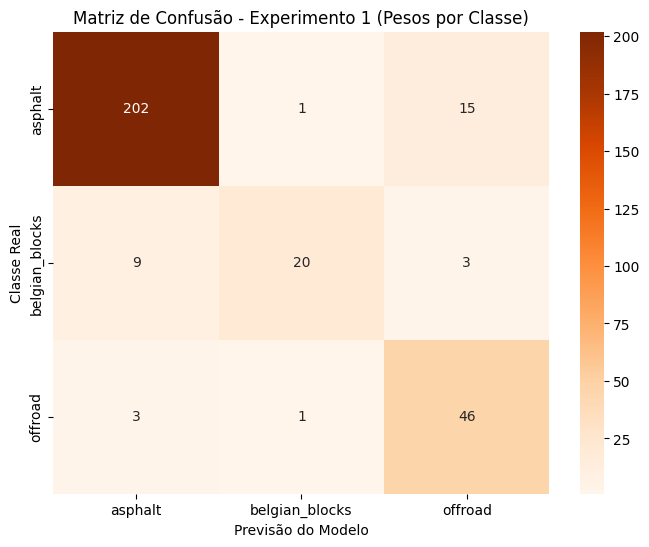

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Obter todos os rótulos do conjunto de treino para calcular os pesos
train_labels = image_datasets['train'].targets

# Calcular os pesos usando a fórmula do scikit-learn (inversamente proporcional à frequência)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Converter o array de pesos para um Tensor do PyTorch e enviar para a GPU
pesos_tensor = torch.tensor(class_weights_array, dtype=torch.float).to(device)

print(f"Pesos calculados para as classes {class_names}:")
print(pesos_tensor.cpu().numpy())
print("-" * 30)

# Configurar o Modelo do Experimento 1
modelo_exp1 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = modelo_exp1.fc.in_features
modelo_exp1.fc = nn.Linear(num_ftrs, len(class_names))
modelo_exp1 = modelo_exp1.to(device)

# Passar os pesos para a função de perda
criterio_exp1 = nn.CrossEntropyLoss(weight=pesos_tensor)

# Otimizador mantém-se igual à baseline para ser uma comparação justa
otimizador_exp1 = optim.Adam(modelo_exp1.parameters(), lr=0.001)

# Treinar o modelo do Experimento 1
print("Iniciando o treinamento do Experimento 1 (Com Pesos)...")
modelo_exp1_treinado = treinar_modelo(modelo_exp1, criterio_exp1, otimizador_exp1, num_epochs=5)

# Avaliar o Experimento 1
modelo_exp1_treinado.eval()
y_true_exp1 = []
y_pred_exp1 = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = modelo_exp1_treinado(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true_exp1.extend(labels.cpu().numpy())
        y_pred_exp1.extend(preds.cpu().numpy())

# Exibir os resultados
print("\n--- Relatório de Classificação - EXPERIMENTO 1 ---")
print(classification_report(y_true_exp1, y_pred_exp1, target_names=class_names))

cm_exp1 = confusion_matrix(y_true_exp1, y_pred_exp1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_exp1, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Experimento 1 (Pesos por Classe)')
plt.show()

**Experimento 2: Data Augmentation (Mudança de transformações de entrada) com Pesos por Classe**

**A hipótese ou motivação:** O dataset apresenta "condições visuais desafiadoras, incluindo variações de iluminação e período noturno". Como tem poucas imagens, o modelo pode memorizar detalhes específicos e falhar no teste. A hipótese é que aplicar transformações aleatórias (rotação, espelhamento e variação de brilho/contraste) simulará essas condições adversas durante o treino, melhorando a capacidade de generalização do modelo.

**O que foi modificado:** Foi adicionado `RandomHorizontalFlip`, `RandomRotation` e `ColorJitter` ao pipeline de pré-processamento (Data Augmentation) do conjunto de treino. Se foi mantido a `CrossEntropyLoss` com os pesos do Experimento 1, unindo as duas estratégias de mitigação.

**Resultados Observados:**
* Melhor Acurácia de Teste: 90.67% (a mais alta atingida entre os testes).
* Recall (Asphalt): Aumentou para impressionantes 98% (214 acertos em 218 imagens).
* Recall (Belgian Blocks): Caiu de 62% (obtido no Experimento 1) para 44% (14 acertos).
* F1-Score Macro: 0.80 (uma leve queda em relação ao 0.83 do Experimento 1).

**Interpretação (Análise Crítica):**
A introdução do Data Augmentation gerou um trade-off (compromisso) claro. Por um lado, as transformações aleatórias ajudaram o modelo a generalizar melhor as características globais do dataset, elevando a acurácia geral e tornando a detecção da classe majoritária quase perfeita.

Por outro lado, o desempenho na classe minoritária foi prejudicado. O pavimento de "Belgian Blocks" depende de padrões geométricos e texturas muito específicas. Ao aplicar rotações e variações de iluminação a um número já extremamente reduzido de exemplos de treino, acaba por distorcer e descaracterizar essa textura geométrica, confundindo a rede. Fica evidente que, para classes com alta escassez de dados baseadas em geometria estruturada, o augmentation agressivo pode acabar sendo contraproducente se não for aplicado de forma controlada.

Iniciando o treinamento do Experimento 2 (Data Augmentation + Pesos)...
Época 1/5
----------
Train Loss: 0.4769 Acc: 0.8178
Test Loss: 5.0048 Acc: 0.7900

Época 2/5
----------
Train Loss: 0.2316 Acc: 0.9144
Test Loss: 1.7383 Acc: 0.8533

Época 3/5
----------
Train Loss: 0.1724 Acc: 0.9467
Test Loss: 0.7395 Acc: 0.9067

Época 4/5
----------
Train Loss: 0.1905 Acc: 0.9378
Test Loss: 0.5330 Acc: 0.8767

Época 5/5
----------
Train Loss: 0.1559 Acc: 0.9400
Test Loss: 0.9982 Acc: 0.8600

Melhor Acurácia de Teste: 0.9067

--- Relatório de Classificação - EXPERIMENTO 2 ---
                precision    recall  f1-score   support

       asphalt       0.91      0.98      0.94       218
belgian_blocks       0.74      0.44      0.55        32
       offroad       0.96      0.88      0.92        50

      accuracy                           0.91       300
     macro avg       0.87      0.77      0.80       300
  weighted avg       0.90      0.91      0.90       300



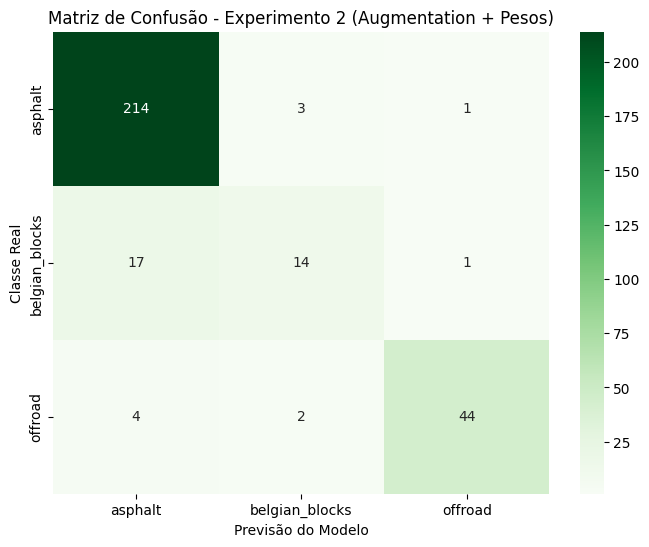

In [ ]:
# Novas transformações com Data Augmentation (apenas para o treino)
data_transforms_aug = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5), 
        transforms.RandomRotation(15),          
        transforms.ColorJitter(brightness=0.2, contrast=0.2), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Recriar os datasets e dataloaders com as novas transformações
image_datasets_aug = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms_aug[x]) for x in ['train', 'test']}
dataloaders_aug = {x: DataLoader(image_datasets_aug[x], batch_size=32, shuffle=True, num_workers=0) for x in ['train', 'test']}

# Configurar um modelo totalmente novo
modelo_exp2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = modelo_exp2.fc.in_features
modelo_exp2.fc = nn.Linear(num_ftrs, len(class_names))
modelo_exp2 = modelo_exp2.to(device)

# Critério (Mantendo os pesos do Experimento 1) e Otimizador
criterio_exp2 = nn.CrossEntropyLoss(weight=pesos_tensor)
otimizador_exp2 = optim.Adam(modelo_exp2.parameters(), lr=0.001)

def treinar_modelo_aug(modelo, criterio, otimizador, num_epochs=5):
    desde = time.time()
    melhor_modelo_wts = copy.deepcopy(modelo.state_dict())
    melhor_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Época {epoch+1}/{num_epochs}')
        print('-' * 10)

        for fase in ['train', 'test']:
            if fase == 'train':
                modelo.train()
            else:
                modelo.eval()

            running_loss = 0.0
            running_corrects = 0

            # Usando o novo dataloader aumentado
            for inputs, labels in dataloaders_aug[fase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                otimizador.zero_grad()

                with torch.set_grad_enabled(fase == 'train'):
                    outputs = modelo(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterio(outputs, labels)

                    if fase == 'train':
                        loss.backward()
                        otimizador.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[fase]
            epoch_acc = running_corrects.double() / dataset_sizes[fase]

            print(f'{fase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if fase == 'test' and epoch_acc > melhor_acc:
                melhor_acc = epoch_acc
                melhor_modelo_wts = copy.deepcopy(modelo.state_dict())
        print()

    print(f'Melhor Acurácia de Teste: {melhor_acc:.4f}')
    modelo.load_state_dict(melhor_modelo_wts)
    return modelo

# Treinar e Avaliar
print("Iniciando o treinamento do Experimento 2 (Data Augmentation + Pesos)...")
modelo_exp2_treinado = treinar_modelo_aug(modelo_exp2, criterio_exp2, otimizador_exp2, num_epochs=5)

# Avaliação Final
modelo_exp2_treinado.eval()
y_true_exp2 = []
y_pred_exp2 = []

with torch.no_grad():
    for inputs, labels in dataloaders_aug['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = modelo_exp2_treinado(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true_exp2.extend(labels.cpu().numpy())
        y_pred_exp2.extend(preds.cpu().numpy())

print("\n--- Relatório de Classificação - EXPERIMENTO 2 ---")
print(classification_report(y_true_exp2, y_pred_exp2, target_names=class_names))

cm_exp2 = confusion_matrix(y_true_exp2, y_pred_exp2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_exp2, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Experimento 2 (Augmentation + Pesos)')
plt.show()

# 4. Resultados

Após o treinamento da solução inicial (Baseline) por 5 épocas, foi realizado a inferência no conjunto de teste para extrair as métricas de avaliação. Para se ter uma visão realista do desempenho, analisa-se além da acurácia global, extraindo o Relatório de Classificação detalhado e a Matriz de Confusão.

**Métricas Obtidas na Solução Inicial (Baseline):**
* Tempo de Treinamento: ~1 minuto e 55 segundos (acelerado via GPU).
* Melhor Acurácia de Teste: 87.00%.
* Recall por Classe (Taxa de Acerto Real):
* Asphalt (218 imagens): 94%
* Offroad (50 imagens): 96%
* Belgian Blocks (32 imagens): 25% (Crítico)

**Interpretação da Baseline:**
Embora a acurácia global de 87% pareça inicialmente um resultado sólido, a análise fragmentada por classe revela o impacto severo do desbalanceamento dos dados. A rede neural adotou um comportamento enviesado: como prever "asfalto" ou "terra" é estatisticamente mais provável de estar correto, o modelo maximizou sua taxa de acerto geral negligenciando a classe minoritária.
A Matriz de Confusão evidencia isso, mostrando que apenas 8 das 32 imagens de Belgian Blocks foram identificadas corretamente, enquanto as demais foram confundidas com os outros pavimentos. Este "ponto cego" do modelo justifica a necessidade de aplicar técnicas de mitigação nas próximas etapas.

Gerando previsões para o conjunto de teste...

--- Relatório de Classificação ---
                precision    recall  f1-score   support

       asphalt       0.94      0.94      0.94       218
belgian_blocks       0.89      0.25      0.39        32
       offroad       0.67      0.96      0.79        50

      accuracy                           0.87       300
     macro avg       0.83      0.72      0.71       300
  weighted avg       0.89      0.87      0.85       300



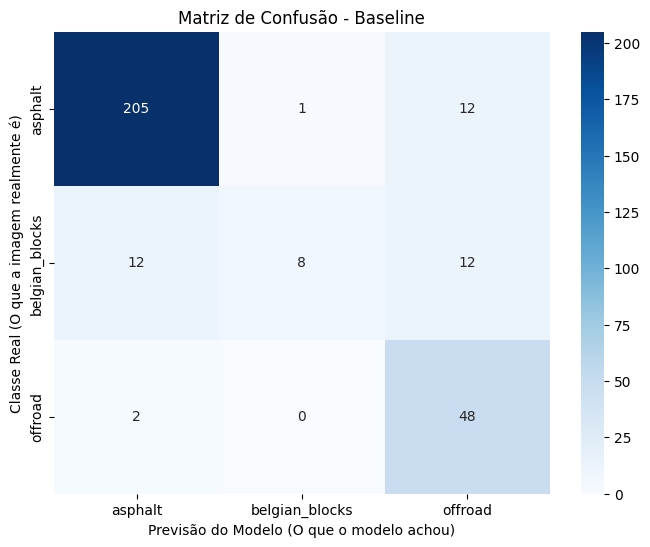

In [14]:
# Colocamos o modelo em modo de avaliação (não aprende mais, só prevê)
modelo_treinado.eval()

y_true = [] # Lista para guardar a classe real
y_pred = [] # Lista para guardar a previsão do modelo

print("Gerando previsões para o conjunto de teste...")

# Desabilitamos o cálculo de gradientes pois não estamos treinando (economiza memória)
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # O modelo dá as probabilidades
        outputs = modelo_treinado(inputs)
        
        # Pegamos a classe com maior probabilidade
        _, preds = torch.max(outputs, 1)
        
        # Movemos os resultados de volta para a CPU para usar no Scikit-Learn
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 1. Relatório de Classificação (Precisão, Recall, F1-Score)
print("\n--- Relatório de Classificação ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Plotando a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão do Modelo (O que o modelo achou)')
plt.ylabel('Classe Real (O que a imagem realmente é)')
plt.title('Matriz de Confusão - Baseline')
plt.show()

# 5. Análise Crítica

A resolução deste desafio de classificação de pavimentos evidenciou a complexidade de se trabalhar com datasets pequenos e altamente desbalanceados no mundo real. Através de uma abordagem sistemática utilizando Transfer Learning (ResNet18), foi possível não apenas criar uma solução funcional, mas compreender as limitações dos dados e as consequências de diferentes estratégias de mitigação.

**Evolução das Métricas e o "Ponto Cego" da Acurácia**
A solução Baseline atingiu rapidamente uma acurácia global de 87%. No entanto, a análise detalhada (Matriz de Confusão e Relatório de Classificação) revelou que esta métrica era ilusória. O modelo adotou um comportamento enviesado, classificando a grande maioria das imagens como a classe majoritária (Asphalt - 94% de recall) e negligenciando quase completamente a classe minoritária (Belgian Blocks - apenas 25% de recall). Isso comprova que, em dados desbalanceados, a avaliação deve ser pautada pelo F1-Score e Recall por classe.

**A Eficácia da Penalização Matemática (Experimento 1)**
O Experimento 1, que introduziu pesos inversamente proporcionais à frequência das classes na função de custo (`CrossEntropyLoss`), provou ser a estratégia de maior sucesso para o problema central. Ao forçar o modelo a "pagar mais caro" pelos erros na classe minoritária, o recall de Belgian Blocks saltou expressivamente de 25% para 62%, com um impacto mínimo na classe majoritária. O F1-Score macro atingiu o seu pico (0.83), indicando o modelo mais equilibrado e confiável gerado neste estudo.

**O Trade-off do Data Augmentation (Experimento 2)**
A aplicação de Data Augmentation no Experimento 2 trouxe uma lição valiosa sobre trade-offs. Embora a acurácia global tenha subido para o seu máximo (90.67%) e a detecção de Asphalt tenha ficado quase perfeita (98%), a classe Belgian Blocks sofreu uma queda de desempenho (44% de recall).
Isso ocorre porque pavimentos de blocos dependem de um padrão visual e geométrico rígido. A aplicação de rotações e distorções a um número já minúsculo de amostras acabou por descaracterizar as features que a rede utilizava para identificar essa classe geométrica, enquanto favoreceu as classes de textura mais caótica (Asfalto e Terra).

**Trabalhos Futuros**
Para evoluir esta solução rumo a um ambiente de produção, as seguintes abordagens seriam recomendadas:
* Coleta de Dados Direcionada: A solução definitiva para o desbalanceamento é a aquisição de mais imagens reais das classes minoritárias (Belgian Blocks e Off-road), sob diferentes condições de iluminação.

* Focal Loss: Substituir a CrossEntropyLoss ponderada por uma Focal Loss, que foca dinamicamente o treinamento nas amostras mais difíceis (onde o modelo tem menos confiança), e não apenas nas classes minoritárias.

* Exploração de Novas Arquiteturas: Testar modelos mais recentes e eficientes na extração de características locais e globais, como a família EfficientNet ou Vision Transformers (ViTs), avaliando o custo computacional e o tempo de inferência.

# 6. Uso de ferramentas

O uso de LLMs foi utilizada ativamente como ferramenta de assistência. Sua contribuição ocorreu nas seguintes frentes:

* **Prototipagem de Código:** Geração de snippets e boilerplates estruturais para os loops de treinamento e avaliação em PyTorch.
* **Discussão Analítica:** A partir da execução do código na minha máquina, utilizei a IA para debater e fundamentar as hipóteses dos resultados obtidos (como o viés da baseline causado pelo desbalanceamento e os trade-offs geométricos gerados pelo Data Augmentation no Experimento 2).
* **Documentação:** Refinamento do tom técnico, estruturação lógica e polimento da redação das análises críticas presentes nas células em Markdown.